# NASA Kepler Objects of Interest - Classification

This notebook prepares the classification track using the NASA Kepler Objects of Interest dataset.

The preprocessing is kept close to the course PDF requirements:

- load and audit the dataset
- check missing values, duplicates, and outliers
- create at least one engineered feature
- split with stratification
- fit imputers/scalers only on training data
- evaluate classifiers with the required classification metrics

## 1. Problem Statement

The task is to predict the official KOI disposition class for a Kepler Object of Interest using tabular measurements from the dataset.

## 2. Dataset Description

Dataset: NASA Kepler Objects of Interest (KOI)

Official source: https://data.nasa.gov/dataset/kepler-objects-of-interest-koi

CSV source used in this notebook: https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv

## 3. Imports and Reproducibility

In [ ]:
from pathlib import Path
import io
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 100)

## 4. Data Loading

In [ ]:
DATA_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv"

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

DATA_PATH = project_root / "data" / "kepler_koi.csv"

if DATA_PATH.exists():
    print(f"Loading local dataset: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
else:
    print("Local dataset not found. Downloading from the Exoplanet Archive...")
    df = pd.read_csv(DATA_URL)
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(DATA_PATH, index=False)
    print(f"Saved dataset to: {DATA_PATH}")

Local dataset not found. Downloading from the Exoplanet Archive...
Saved dataset to: C:\Users\domin\OneDrive\Desktop\Amrita'\Sem 5\Machine Learning\project\ML-Capstone_project\data\kepler_koi.csv


## 5. Dataset Audit

In [ ]:
display(df.head())
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,koi_gmag_err,koi_rmag,koi_rmag_err,koi_imag,koi_imag_err,koi_zmag,koi_zmag_err,koi_jmag,koi_jmag_err,koi_hmag,koi_hmag_err,koi_kmag,koi_kmag_err,koi_kepmag,koi_kepmag_err,koi_delivname,koi_vet_stat,koi_quarters,koi_disposition,koi_pdisposition,koi_count,koi_num_transits,koi_max_sngle_ev,koi_max_mult_ev,koi_bin_oedp_sig,koi_limbdark_mod,koi_ldm_coeff4,koi_ldm_coeff3,koi_ldm_coeff2,koi_ldm_coeff1,koi_trans_mod,koi_model_snr,koi_model_dof,koi_model_chisq,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_eccen,koi_eccen_err1,koi_eccen_err2,...,koi_sage_err2,koi_sparprov,koi_fwm_stat_sig,koi_fwm_sra,koi_fwm_sra_err,koi_fwm_sdec,koi_fwm_sdec_err,koi_fwm_srao,koi_fwm_srao_err,koi_fwm_sdeco,koi_fwm_sdeco_err,koi_fwm_prao,koi_fwm_prao_err,koi_fwm_pdeco,koi_fwm_pdeco_err,koi_dicco_mra,koi_dicco_mra_err,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err,koi_comment,koi_vet_date,koi_tce_plnt_num,koi_tce_delivname,koi_datalink_dvs,koi_disp_prov,koi_parm_prov,koi_time0,koi_time0_err1,koi_time0_err2,koi_datalink_dvr,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score
0,10797460,K00752.01,Kepler-227 b,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,NaN,15.270,NaN,15.114,NaN,15.006,NaN,14.082,0.025,13.751,0.030,13.648,0.054,15.347,NaN,cumulative,Done,11111111111111111000000000000000,CONFIRMED,CANDIDATE,2,142.0,5.135849,28.470820,0.6864,Claret (2011 A&A 529 75) ATLAS LS,0.0,0.0,0.2291,0.4603,Mandel and Agol (2002 ApJ 580 171),35.8,NaN,NaN,170.538750,0.002160,-0.002160,0.0,NaN,NaN,...,NaN,q1_q17_dr25_stellar,0.002,19.462294,1.400000e-05,48.14191,0.000130,0.430,0.510,0.940,0.480,-0.00020,0.00032,-0.00055,0.00031,-0.010,0.130,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160,NO_COMMENT,2018-08-16 00:00:00,1.0,q1_q17_dr25_tce,010/010797/010797460/dv/kplr010797460-001-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2455003.539,0.002160,-0.002160,010/010797/010797460/dv/kplr010797460-20160209...,0,0,0,0,93.59,29.45,-16.65,3.20796,0.33173,-1.09986,LS+MCMC,1.000
1,10797460,K00752.02,Kepler-227 c,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,NaN,15.270,NaN,15.114,NaN,15.006,NaN,14.082,0.025,13.751,0.030,13.648,0.054,15.347,NaN,cumulative,Done,11111111111111111000000000000000,CONFIRMED,CANDIDATE,2,25.0,7.027669,20.109507,0.0023,Claret (2011 A&A 529 75) ATLAS LS,0.0,0.0,0.2291,0.4603,Mandel and Agol (2002 ApJ 580 171),25.8,NaN,NaN,162.513840,0.003520,-0.003520,0.0,NaN,NaN,...,NaN,q1_q17_dr25_stellar,0.003,19.462265,2.000000e-05,48.14199,0.000190,-0.630,0.720,1.230,0.680,0.00066,0.00065,-0.00105,0.00063,0.390,0.360,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450,NO_COMMENT,2018-08-16 00:00:00,2.0,q1_q17_dr25_tce,010/010797/010797460/dv/kplr010797460-002-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2454995.514,0.003520,-0.003520,010/010797/010797460/dv/kplr010797460-20160209...,0,0,0,0,9.11,2.87,-1.62,3.02368,2.20489,-2.49638,LS+MCMC,0.969
2,10811496,K00753.01,NaN,297.00482,0.0,19h48m01.16s,48.134129,0.0,+48d08m02.9s,15.943,NaN,15.390,NaN,15.220,NaN,15.166,NaN,14.254,0.028,13.900,0.033,13.826,0.058,15.436,NaN,cumulative,Done,11111101110111011000000000000000,CANDIDATE,CANDIDATE,1,56.0,37.159767,187.449100,0.6624,Claret (2011 A&A 529 75) ATLAS LS,0.0,0.0,0.2711,0.3858,Mandel and Agol (2002 ApJ 580 171),76.3,NaN,NaN,175.850252,0.000581,-0.000581,0.0,NaN,NaN,...,NaN,q1_q17_dr25_stellar,0.278,19.800321,1.900000e-06,48.13412,0.000020,-0.021,0.069,-0.038,0.071,0.00070,0.00240,0.00060,0.00340,-0.025,0.070,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074,DEEP_V_SHAPED,2018-08-16 00:00:00,1.0,q1_q17_dr25_tce,010/010811/010811496/dv/kplr010811496-001-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2455008.850,0.000581,-0.000

Shape: 9,564 rows x 153 columns


In [ ]:
print("Columns:")
print(df.columns.tolist())

Columns:
['kepid', 'kepoi_name', 'kepler_name', 'ra', 'ra_err', 'ra_str', 'dec', 'dec_err', 'dec_str', 'koi_gmag', 'koi_gmag_err', 'koi_rmag', 'koi_rmag_err', 'koi_imag', 'koi_imag_err', 'koi_zmag', 'koi_zmag_err', 'koi_jmag', 'koi_jmag_err', 'koi_hmag', 'koi_hmag_err', 'koi_kmag', 'koi_kmag_err', 'koi_kepmag', 'koi_kepmag_err', 'koi_delivname', 'koi_vet_stat', 'koi_quarters', 'koi_disposition', 'koi_pdisposition', 'koi_count', 'koi_num_transits', 'koi_max_sngle_ev', 'koi_max_mult_ev', 'koi_bin_oedp_sig', 'koi_limbdark_mod', 'koi_ldm_coeff4', 'koi_ldm_coeff3', 'koi_ldm_coeff2', 'koi_ldm_coeff1', 'koi_trans_mod', 'koi_model_snr', 'koi_model_dof', 'koi_model_chisq', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_eccen', 'koi_eccen_err1', 'koi_eccen_err2', 'koi_longp', 'koi_longp_err1', 'koi_longp_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_sma', 'koi_sma_err1', 'koi_sma_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err

In [ ]:
info_buffer = io.StringIO()
df.info(buf=info_buffer)
print(info_buffer.getvalue())

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Columns: 153 entries, kepid to koi_score
dtypes: float64(127), int64(6), object(1), str(19)
memory usage: 14.6+ MB



In [ ]:
audit_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(dropna=True),
})

display(audit_table.sort_values("missing_percent", ascending=False))

,dtype,missing_count,missing_percent,unique_values
koi_gmag_err,float64,9564,100.0,0
koi_imag_err,float64,9564,100.0,0
koi_zmag_err,float64,9564,100.0,0
koi_rmag_err,float64,9564,100.0,0
koi_kepmag_err,float64,9564,100.0,0
...,...,...,...,...
koi_fpflag_nt,int64,0,0.0,3
koi_time0,float64,0,0.0,7445
koi_fpflag_co,int64,0,0.0,2
koi_fpflag_ss,int64,0,0.0,2


## 6. Target Definition

In [ ]:
target_column = "koi_disposition"

if target_column not in df.columns:
    raise KeyError(f"Target column not found: {target_column}")

class_counts = df[target_column].value_counts()
class_percentages = df[target_column].value_counts(normalize=True).mul(100).round(2)
target_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages,
})

print(f"Selected classification target: {target_column}")
print(f"Target classes: {sorted(df[target_column].dropna().unique().tolist())}")
display(target_distribution)

Selected classification target: koi_disposition
Target classes: ['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE']


,count,percentage
koi_disposition,,
FALSE POSITIVE,4839,50.60
CONFIRMED,2748,28.73
CANDIDATE,1977,20.67


`koi_disposition` is used as the target because it directly stores the KOI disposition classes in the dataset.

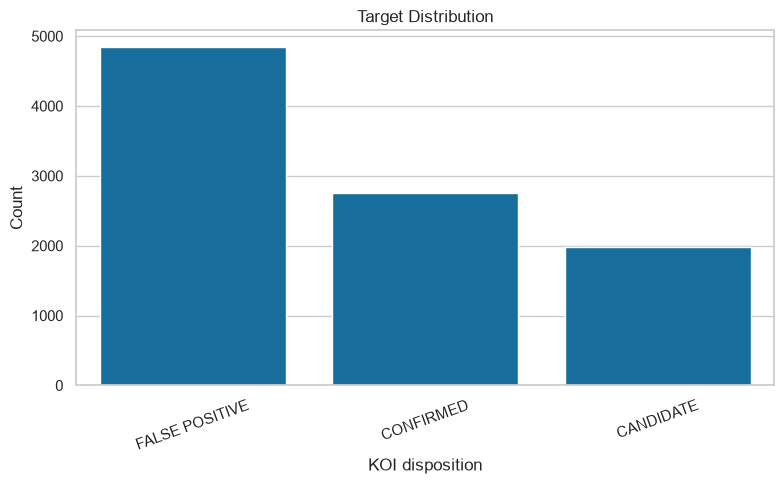

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_column, order=class_counts.index)
plt.title("Target Distribution")
plt.xlabel("KOI disposition")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

> STUDENT OBSERVATION TODO: Comment on the class distribution after running the notebook.

## 7. Exploratory Data Analysis

In [ ]:
eda_features = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_model_snr",
    "koi_steff",
    "koi_slogg",
    "koi_srad",
    "koi_smass",
]

eda_features = [column for column in eda_features if column in df.columns]
display(df[eda_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
koi_period,9564.0,75.671358,1334.744046,0.241843,2.733684,9.752831,40.715178,1.299958e+05
koi_duration,9564.0,5.621606,6.471554,0.052000,2.437750,3.792600,6.276500,1.385400e+02
koi_depth,9201.0,23791.343984,82242.684708,0.000000,159.900000,421.100000,1473.400000,1.541400e+06
koi_prad,9201.0,102.891778,3077.639126,0.080000,1.400000,2.390000,14.930000,2.003460e+05
koi_teq,9201.0,1085.385828,856.351161,25.000000,539.000000,878.000000,1379.000000,1.466700e+04
koi_insol,9243.0,7745.737023,159204.665200,0.000000,20.150000,141.600000,870.290000,1.094755e+07
koi_model_snr,9201.0,259.895001,795.806615,0.000000,12.000000,23.000000,78.000000,9.054700e+03
koi_steff,9201.0,5706.823280,796.857947,2661.000000,5310.000000,5767.000000,6112.000000,1.589600e+04
koi_slogg,9201.0,4.310157,0.432606,0.047000,4.218000,4.438000,4.543000,5.364000e+00
koi_srad,9201.0,1.728712,6.127185,0.109000,0.829000,1.000000,1.345000,2.299080e+02


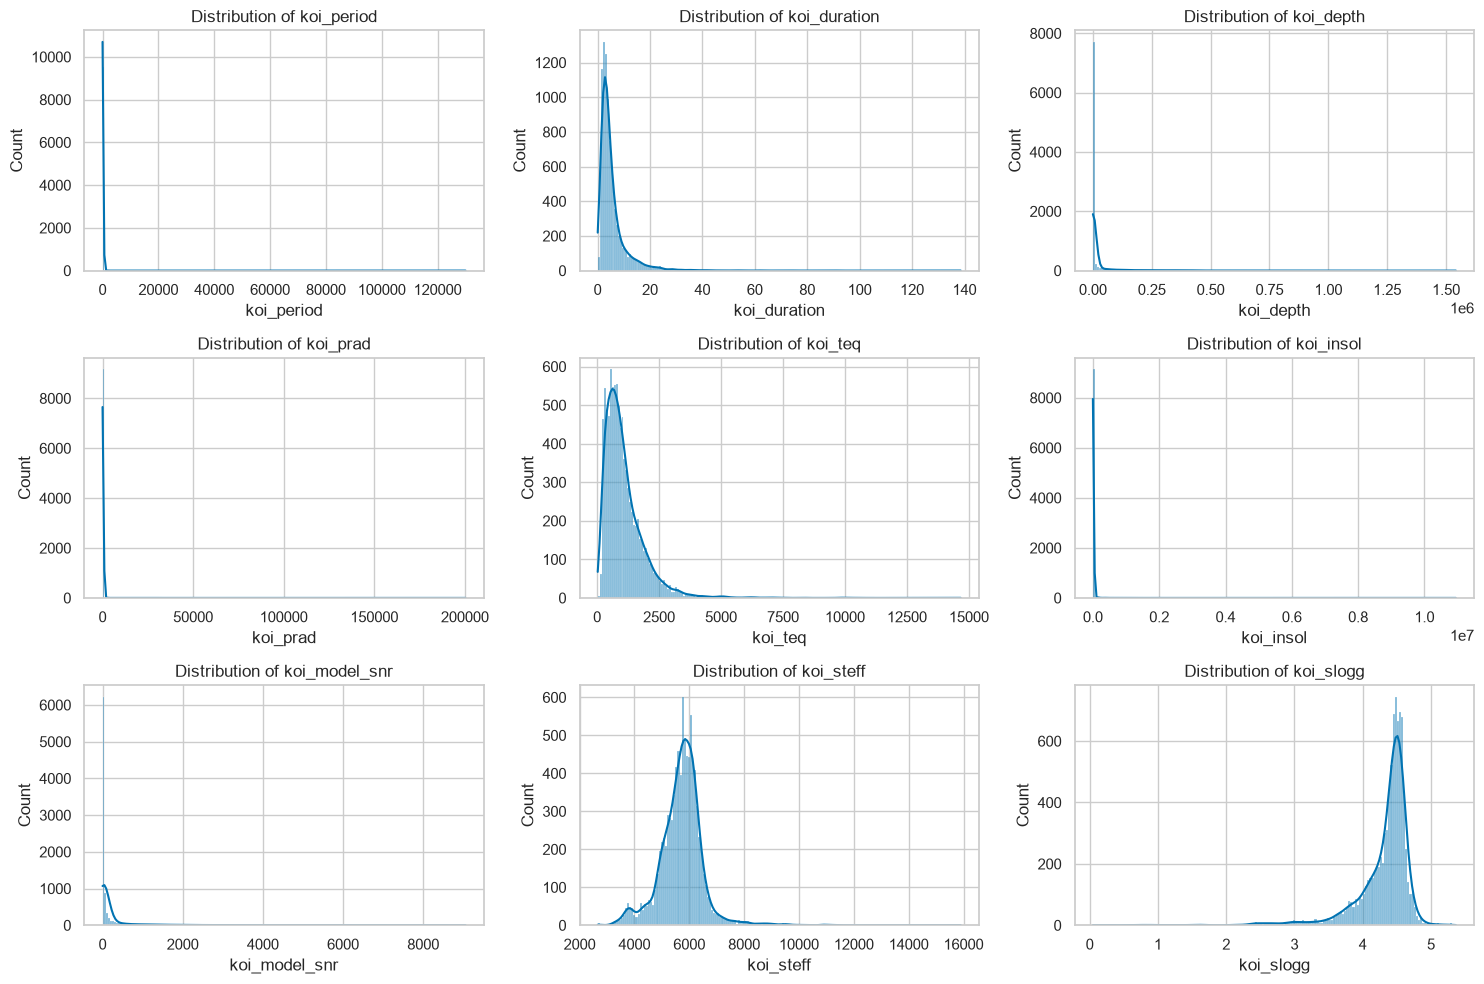

In [ ]:
plot_features = eda_features[:9]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for axis, column in zip(axes, plot_features):
    sns.histplot(df[column], kde=True, ax=axis)
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Count")

for axis in axes[len(plot_features):]:
    axis.set_visible(False)

plt.tight_layout()
plt.show()

> STUDENT OBSERVATION TODO: Add a short observation about the distribution plots.

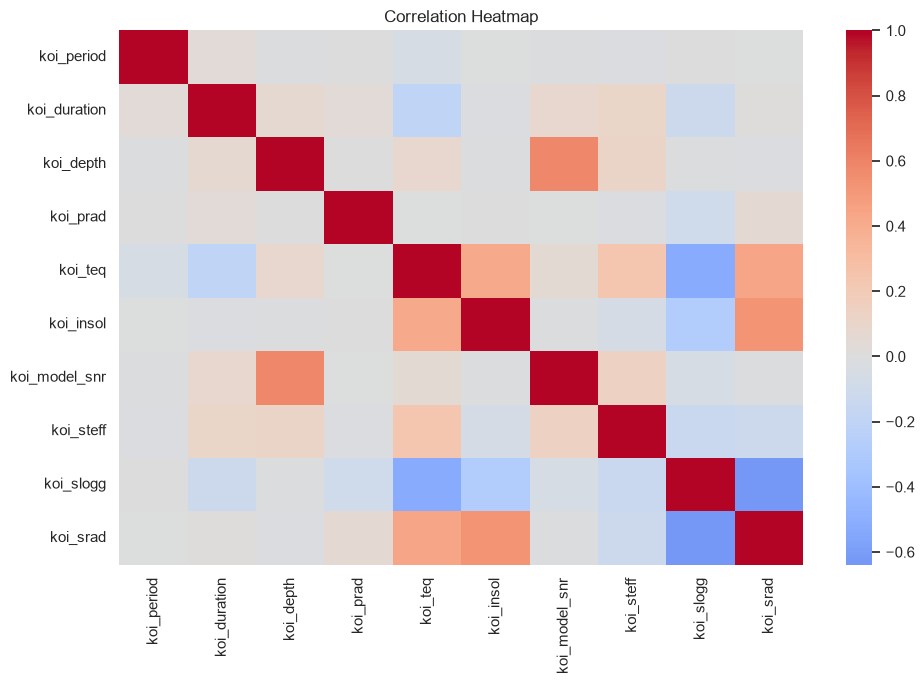

In [ ]:
correlation_features = eda_features[:10]

plt.figure(figsize=(10, 7))
sns.heatmap(df[correlation_features].corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

> STUDENT OBSERVATION TODO: Add a short observation about the correlation heatmap.

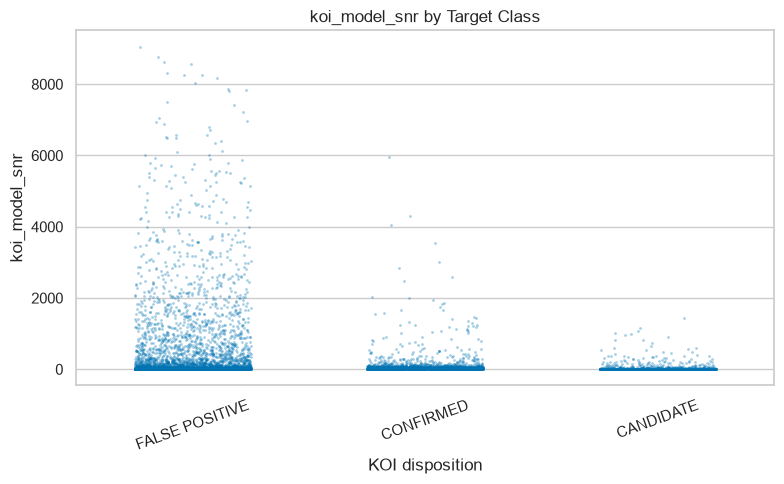

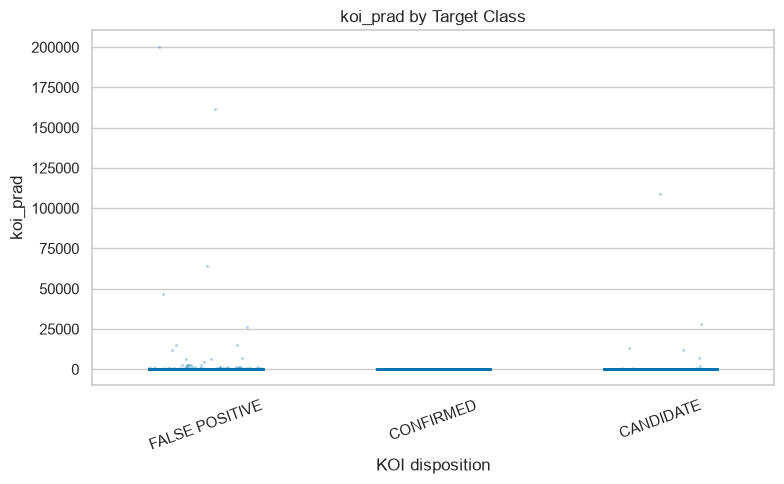

In [ ]:
scatter_features = [column for column in ["koi_model_snr", "koi_prad"] if column in df.columns]

for column in scatter_features:
    plt.figure(figsize=(8, 5))
    sns.stripplot(
        data=df,
        x=target_column,
        y=column,
        order=class_counts.index,
        jitter=0.25,
        alpha=0.35,
        size=2,
    )
    plt.title(f"{column} by Target Class")
    plt.xlabel("KOI disposition")
    plt.ylabel(column)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

> STUDENT OBSERVATION TODO: Add a short observation about the two feature-target scatter plots.

## 8. Data Cleaning

In [ ]:
working_df = df.copy()

duplicate_count = working_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")

if duplicate_count > 0:
    working_df = working_df.drop_duplicates().copy()
    print(f"Removed {duplicate_count:,} exact duplicate rows.")
else:
    print("No exact duplicate rows found.")

Number of duplicate rows: 0
No exact duplicate rows found.


In [ ]:
missing_summary = (
    working_df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"].div(len(working_df)).mul(100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

,missing_count,missing_percent
koi_incl_err1,9564,100.00
koi_ingress_err2,9564,100.00
koi_eccen_err1,9564,100.00
koi_eccen_err2,9564,100.00
koi_longp,9564,100.00
...,...,...
koi_kmag,25,0.26
koi_jmag,25,0.26
koi_hmag,25,0.26
koi_rmag,9,0.09


In [ ]:
outlier_rows = []
for column in eda_features:
    values = working_df[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((values < lower) | (values > upper)).sum()
    outlier_rows.append({
        "feature": column,
        "potential_outliers": int(outlier_count),
        "outlier_percent": round(outlier_count / len(values) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

,feature,potential_outliers,outlier_percent
0,koi_period,1567,16.38
1,koi_duration,869,9.09
2,koi_depth,1798,19.54
3,koi_prad,1469,15.97
4,koi_teq,411,4.47
5,koi_insol,1438,15.56
6,koi_model_snr,1600,17.39
7,koi_steff,552,6.00
8,koi_slogg,663,7.21
9,koi_srad,985,10.71


Missing values are handled later by imputers fitted on training data only. Potential outliers are checked, but not automatically deleted, because extreme astronomical measurements can still be valid observations.

## 9. Feature Engineering

In [ ]:
if {"koi_depth", "koi_duration"}.issubset(working_df.columns):
    working_df["transit_depth_per_hour"] = (
        working_df["koi_depth"] / working_df["koi_duration"].replace(0, np.nan)
    )
    engineered_features = ["transit_depth_per_hour"]
else:
    engineered_features = []

print("Engineered features:", engineered_features)
if engineered_features:
    display(working_df[engineered_features].describe().T)

Engineered features: ['transit_depth_per_hour']


,count,mean,std,min,25%,50%,75%,max
transit_depth_per_hour,9201.0,4818.271031,17645.246313,0.0,38.435766,112.014712,444.746295,416155.623346


`transit_depth_per_hour` is calculated as `koi_depth / koi_duration`.

> STUDENT JUSTIFICATION TODO: Explain why this engineered feature may help model performance after reviewing the outputs.

## 10. Feature and Target Split

In [ ]:
rows_before = len(working_df)
modeling_df = working_df.dropna(subset=[target_column]).copy()
print(f"Rows removed because target is missing: {rows_before - len(modeling_df):,}")

columns_not_used = {
    target_column: "target column",
    "kepid": "identifier column",
    "koi_pdisposition": "another disposition label",
    "koi_score": "disposition score related to the target",
    "koi_fpflag_nt": "false-positive flag related to target decision",
    "koi_fpflag_ss": "false-positive flag related to target decision",
    "koi_fpflag_co": "false-positive flag related to target decision",
    "koi_fpflag_ec": "false-positive flag related to target decision",
}

columns_not_used = {
    column: reason
    for column, reason in columns_not_used.items()
    if column in modeling_df.columns
}

display(
    pd.DataFrame(
        [{"Column": column, "Reason": reason} for column, reason in columns_not_used.items()]
    )
)

Rows removed because target is missing: 0


,Column,Reason
0,koi_disposition,target column
1,kepid,identifier column
2,koi_pdisposition,another disposition label
3,koi_score,disposition score related to the target
4,koi_fpflag_nt,false-positive flag related to target decision
5,koi_fpflag_ss,false-positive flag related to target decision
6,koi_fpflag_co,false-positive flag related to target decision
7,koi_fpflag_ec,false-positive flag related to target decision


In [ ]:
numeric_columns = modeling_df.select_dtypes(include=[np.number]).columns.tolist()
feature_columns = [column for column in numeric_columns if column not in columns_not_used]

all_missing_features = [column for column in feature_columns if modeling_df[column].isna().all()]
constant_features = [
    column for column in feature_columns
    if column not in all_missing_features and modeling_df[column].nunique(dropna=True) <= 1
]

feature_columns = [
    column for column in feature_columns
    if column not in set(all_missing_features + constant_features)
]

removed_feature_summary = pd.DataFrame([
    {"Column": column, "Reason": "all values are missing"}
    for column in all_missing_features
] + [
    {"Column": column, "Reason": "constant value"}
    for column in constant_features
])

if not removed_feature_summary.empty:
    display(removed_feature_summary.sort_values("Column"))

X = modeling_df[feature_columns].copy()
y = modeling_df[target_column].astype(str).copy()

numeric_features = feature_columns
categorical_features = []

print(f"Number of modelling features: {len(feature_columns)}")
print("Categorical features selected:", categorical_features)
print("Numerical features selected:")
print(numeric_features)

,Column,Reason
25,dec_err,constant value
28,koi_eccen,constant value
7,koi_eccen_err1,all values are missing
8,koi_eccen_err2,all values are missing
0,koi_gmag_err,all values are missing
2,koi_imag_err,all values are missing
17,koi_incl_err1,all values are missing
18,koi_incl_err2,all values are missing
14,koi_ingress,all values are missing
15,koi_ingress_err1,all values are missing


Number of modelling features: 99
Categorical features selected: []
Numerical features selected:
['ra', 'dec', 'koi_gmag', 'koi_rmag', 'koi_imag', 'koi_zmag', 'koi_jmag', 'koi_jmag_err', 'koi_hmag', 'koi_hmag_err', 'koi_kmag', 'koi_kmag_err', 'koi_kepmag', 'koi_count', 'koi_num_transits', 'koi_max_sngle_ev', 'koi_max_mult_ev', 'koi_bin_oedp_sig', 'koi_ldm_coeff2', 'koi_ldm_coeff1', 'koi_model_snr', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2', 'koi_sma', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_ror', 'koi_ror_err1', 'koi_ror_err2', 'koi_dor', 'koi_dor_err1', 'koi_dor_err2', 'koi_incl', 'koi_teq', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_smet', 'koi_smet_err1', 'koi_smet_err2', 'koi_srad', 'koi_srad_e

This notebook uses numeric modelling features only. Text labels, names, comments, links, and provenance columns are left out to keep preprocessing simple and explainable for Review 1.

## 11. Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

display(pd.DataFrame({
    "train_percent": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_percent": y_test.value_counts(normalize=True).mul(100).round(2),
}))

X_train: (7651, 99)
X_test: (1913, 99)
y_train: (7651,)
y_test: (1913,)


,train_percent,test_percent
koi_disposition,,
FALSE POSITIVE,50.59,50.60
CONFIRMED,28.73,28.75
CANDIDATE,20.68,20.65


## 12. Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Preprocessing will be fitted only inside model pipelines using X_train.")

Preprocessing will be fitted only inside model pipelines using X_train.


Preprocessing follows the PDF rule: imputing and scaling are fitted on the training set only through the sklearn pipeline, then applied to the test set through the same fitted pipeline.

## 13. Gaussian Naive Bayes

Gaussian Naive Bayes applies Bayes' theorem with a Gaussian likelihood assumption for continuous features. It is simple and explainable, but correlated features can weaken the conditional independence assumption.

In [1]:
def calculate_roc_auc(y_true, probabilities, classes):
    if len(classes) == 2:
        return roc_auc_score(y_true, probabilities[:, 1])

    y_true_binarized = label_binarize(y_true, classes=classes)
    return roc_auc_score(
        y_true_binarized,
        probabilities,
        multi_class="ovr",
        average="weighted",
    )


def show_confusion_matrix(y_true, predictions, classes, title):
    matrix = confusion_matrix(y_true, predictions, labels=classes)
    display_matrix = ConfusionMatrixDisplay(matrix, display_labels=classes)
    display_matrix.plot(cmap="Blues", xticks_rotation=25)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.tight_layout()
    plt.show()

In [ ]:
gnb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GaussianNB()),
])

gnb_pipeline.fit(X_train, y_train)

gnb_predictions = gnb_pipeline.predict(X_test)
gnb_probabilities = gnb_pipeline.predict_proba(X_test)
gnb_classes = gnb_pipeline.classes_

gnb_metrics = {
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy_score(y_test, gnb_predictions),
    "Precision_Weighted": precision_score(y_test, gnb_predictions, average="weighted", zero_division=0),
    "Recall_Weighted": recall_score(y_test, gnb_predictions, average="weighted", zero_division=0),
    "F1_Weighted": f1_score(y_test, gnb_predictions, average="weighted", zero_division=0),
    "ROC_AUC_OvR": calculate_roc_auc(y_test, gnb_probabilities, gnb_classes),
}

print("Gaussian Naive Bayes classification report")
print(classification_report(y_test, gnb_predictions, labels=gnb_classes, zero_division=0))

display(pd.DataFrame([gnb_metrics]).round(4))

## 14. Decision Tree Classifier

In [ ]:
tree_baseline_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

tree_baseline_pipeline.fit(X_train, y_train)

tree_baseline_predictions = tree_baseline_pipeline.predict(X_test)
tree_baseline_probabilities = tree_baseline_pipeline.predict_proba(X_test)
tree_baseline_classes = tree_baseline_pipeline.classes_

tree_baseline_metrics = {
    "Model": "Decision Tree Classifier - Baseline",
    "Accuracy": accuracy_score(y_test, tree_baseline_predictions),
    "Precision_Weighted": precision_score(y_test, tree_baseline_predictions, average="weighted", zero_division=0),
    "Recall_Weighted": recall_score(y_test, tree_baseline_predictions, average="weighted", zero_division=0),
    "F1_Weighted": f1_score(y_test, tree_baseline_predictions, average="weighted", zero_division=0),
    "ROC_AUC_OvR": calculate_roc_auc(y_test, tree_baseline_probabilities, tree_baseline_classes),
}

print("Decision Tree baseline classification report")
print(classification_report(y_test, tree_baseline_predictions, labels=tree_baseline_classes, zero_division=0))

display(pd.DataFrame([tree_baseline_metrics]).round(4))

## 15. Decision Tree Hyperparameter Tuning

In [ ]:
tree_tuning_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

param_grid = {
    "model__max_depth": [None, 3, 5, 8, 10],
}

tree_grid_search = GridSearchCV(
    tree_tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
)

tree_grid_search.fit(X_train, y_train)
tuned_tree_pipeline = tree_grid_search.best_estimator_

tuned_tree_predictions = tuned_tree_pipeline.predict(X_test)
tuned_tree_probabilities = tuned_tree_pipeline.predict_proba(X_test)
tuned_tree_classes = tuned_tree_pipeline.classes_

tuned_tree_metrics = {
    "Model": "Decision Tree Classifier - Tuned",
    "Accuracy": accuracy_score(y_test, tuned_tree_predictions),
    "Precision_Weighted": precision_score(y_test, tuned_tree_predictions, average="weighted", zero_division=0),
    "Recall_Weighted": recall_score(y_test, tuned_tree_predictions, average="weighted", zero_division=0),
    "F1_Weighted": f1_score(y_test, tuned_tree_predictions, average="weighted", zero_division=0),
    "ROC_AUC_OvR": calculate_roc_auc(y_test, tuned_tree_probabilities, tuned_tree_classes),
}

print("Tuned Decision Tree classification report")
print(classification_report(y_test, tuned_tree_predictions, labels=tuned_tree_classes, zero_division=0))

display(pd.DataFrame([
    {"Item": "Best max_depth", "Value": tree_grid_search.best_params_["model__max_depth"]},
    {"Item": "Best CV weighted F1", "Value": round(tree_grid_search.best_score_, 4)},
    {"Item": "Baseline test weighted F1", "Value": round(tree_baseline_metrics["F1_Weighted"], 4)},
    {"Item": "Tuned test weighted F1", "Value": round(tuned_tree_metrics["F1_Weighted"], 4)},
]))

## 16. Evaluation Visualisations

In [ ]:
show_confusion_matrix(y_test, gnb_predictions, gnb_pipeline.classes_, "Gaussian Naive Bayes Confusion Matrix")
show_confusion_matrix(y_test, tree_baseline_predictions, tree_baseline_pipeline.classes_, "Decision Tree Baseline Confusion Matrix")
show_confusion_matrix(y_test, tuned_tree_predictions, tuned_tree_pipeline.classes_, "Decision Tree Tuned Confusion Matrix")

In [ ]:
classes = tuned_tree_pipeline.classes_
y_test_binarized = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))
for class_index, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, class_index], tuned_tree_probabilities[:, class_index])
    plt.plot(fpr, tpr, label=class_name)

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.title("Tuned Decision Tree OvR ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Model Comparison

In [ ]:
comparison_table = pd.DataFrame([
    gnb_metrics,
    tree_baseline_metrics,
    tuned_tree_metrics,
]).round(4)

comparison_table = comparison_table.sort_values("F1_Weighted", ascending=False).reset_index(drop=True)
display(comparison_table)

> STUDENT OBSERVATION TODO: Compare models using the final table and confusion matrices.

## 18. Decision Tree Visualisation and Feature Importance

In [ ]:
fitted_preprocessor = tuned_tree_pipeline.named_steps["preprocess"]
fitted_tree = tuned_tree_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 10))
plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=fitted_tree.classes_,
    max_depth=3,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
)
plt.title("Tuned Decision Tree - Top Levels")
plt.tight_layout()
plt.show()

In [ ]:
feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": fitted_tree.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance.head(15), y="Feature", x="Importance")
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

> STUDENT OBSERVATION TODO: Explain which features appear important after checking the table.

## 19. Remaining Classification Part-A Models

The course PDF lists five Part-A classifiers for Review 1:

- Logistic Regression
- K-Nearest Neighbors
- Gaussian Naive Bayes
- Decision Tree Classifier
- Support Vector Machine

Only Gaussian Naive Bayes and Decision Tree are implemented in this notebook version. The remaining models should use the same split and comparison-table format when added.

## 20. Support Vector Classifier (SVC)

Support Vector Classifier finds the decision boundary that separates the classes with the widest possible
margin, defined by the support vectors (the hardest, boundary-defining points). With the RBF kernel it can
draw curved boundaries by comparing objects in a transformed space (the kernel trick), and it handles the
three KOI classes with a one-vs-one scheme internally.

- **Why scaling:** the RBF kernel is distance-based, so features must be standardised. SVC sits behind the
  shared `preprocessor` (median impute + scale), fit on training folds only.
- **Key knobs:** `C` (margin softness, higher C fits the training data harder), `gamma` (RBF reach), and
  `kernel` (rbf vs linear). These are tuned with `GridSearchCV` on weighted F1, matching the Decision Tree
  tuning above.
- **Probabilities:** `probability=True` so we can report the one-vs-rest ROC-AUC alongside accuracy and
  weighted precision, recall and F1.

In [30]:
#svc import
from sklearn.svm import SVC

#same pipeline shape as the other classifiers; probability=True enables ROC-AUC
svc_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVC(probability=True, random_state=RANDOM_STATE)),
])

#tune C, gamma and kernel on weighted F1 (same scoring and cv as the tree)
svc_param_grid = [
    {"model__kernel": ["rbf"], "model__C": [1, 10, 100], "model__gamma": ["scale", 0.01]},
    {"model__kernel": ["linear"], "model__C": [1, 10]},
]

svc_grid_search = GridSearchCV(
    svc_pipeline, param_grid=svc_param_grid,
    scoring="f1_weighted", cv=5, n_jobs=-1,
)
svc_grid_search.fit(X_train, y_train)
svc_pipeline_best = svc_grid_search.best_estimator_

svc_predictions = svc_pipeline_best.predict(X_test)
svc_probabilities = svc_pipeline_best.predict_proba(X_test)
svc_classes = svc_pipeline_best.classes_

svc_metrics = {
    "Model": "Support Vector Classifier",
    "Accuracy": accuracy_score(y_test, svc_predictions),
    "Precision_Weighted": precision_score(y_test, svc_predictions, average="weighted", zero_division=0),
    "Recall_Weighted": recall_score(y_test, svc_predictions, average="weighted", zero_division=0),
    "F1_Weighted": f1_score(y_test, svc_predictions, average="weighted", zero_division=0),
    "ROC_AUC_OvR": calculate_roc_auc(y_test, svc_probabilities, svc_classes),
}

print("Best SVC parameters:", svc_grid_search.best_params_)
print("Best CV weighted F1:", round(svc_grid_search.best_score_, 4))
print("\nSupport Vector Classifier classification report")
print(classification_report(y_test, svc_predictions, labels=svc_classes, zero_division=0))

display(pd.DataFrame([svc_metrics]).round(4))

Best SVC parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV weighted F1: 0.8193

Support Vector Classifier classification report
                precision    recall  f1-score   support

     CANDIDATE       0.62      0.57      0.60       395
     CONFIRMED       0.86      0.90      0.88       550
FALSE POSITIVE       0.87      0.88      0.88       968

      accuracy                           0.82      1913
     macro avg       0.79      0.78      0.78      1913
  weighted avg       0.82      0.82      0.82      1913



,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,ROC_AUC_OvR
0,Support Vector Classifier,0.8223,0.8179,0.8223,0.8197,0.9442


### Chosen hyperparameters

The grid picked `kernel='rbf'`, `C=10`, `gamma='scale'` (best CV weighted F1 about 0.82). A moderate `C` with
the default `scale` gamma is a mild RBF fit; the grid preferred it over a harder `C=100`, a more local
`gamma=0.01`, and the linear kernel, so a gentle non-linear boundary generalises best on these transit
features.

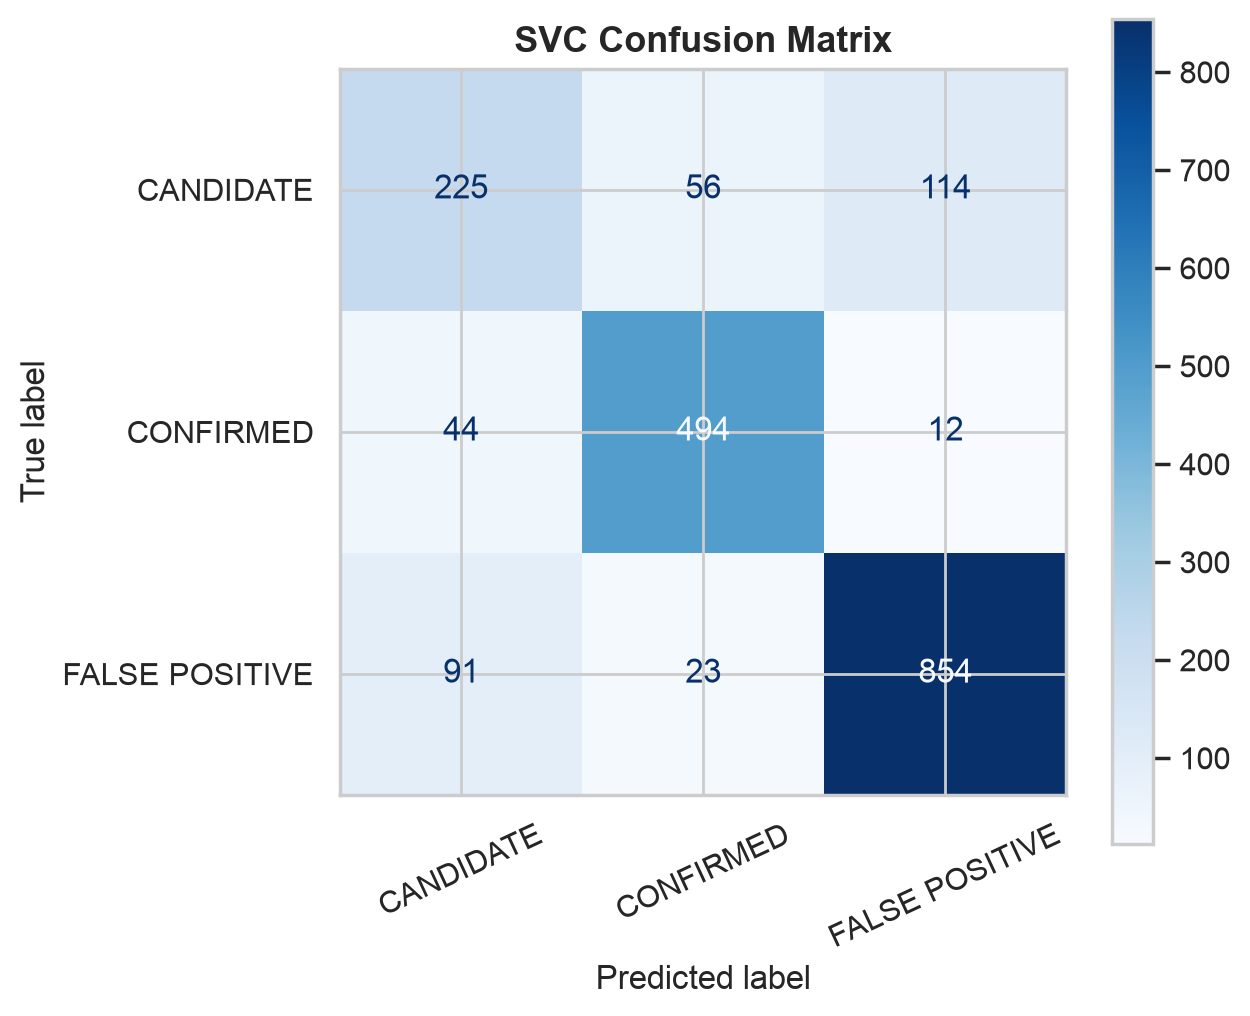

In [31]:
#confusion matrix for svc, saved under figures/SVC/
import os
os.makedirs("figures/SVC", exist_ok=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=200)
ConfusionMatrixDisplay(
    confusion_matrix(y_test, svc_predictions, labels=svc_classes),
    display_labels=svc_classes,
).plot(cmap="Blues", ax=ax, xticks_rotation=25, colorbar=True)
ax.set_title("SVC Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/SVC/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

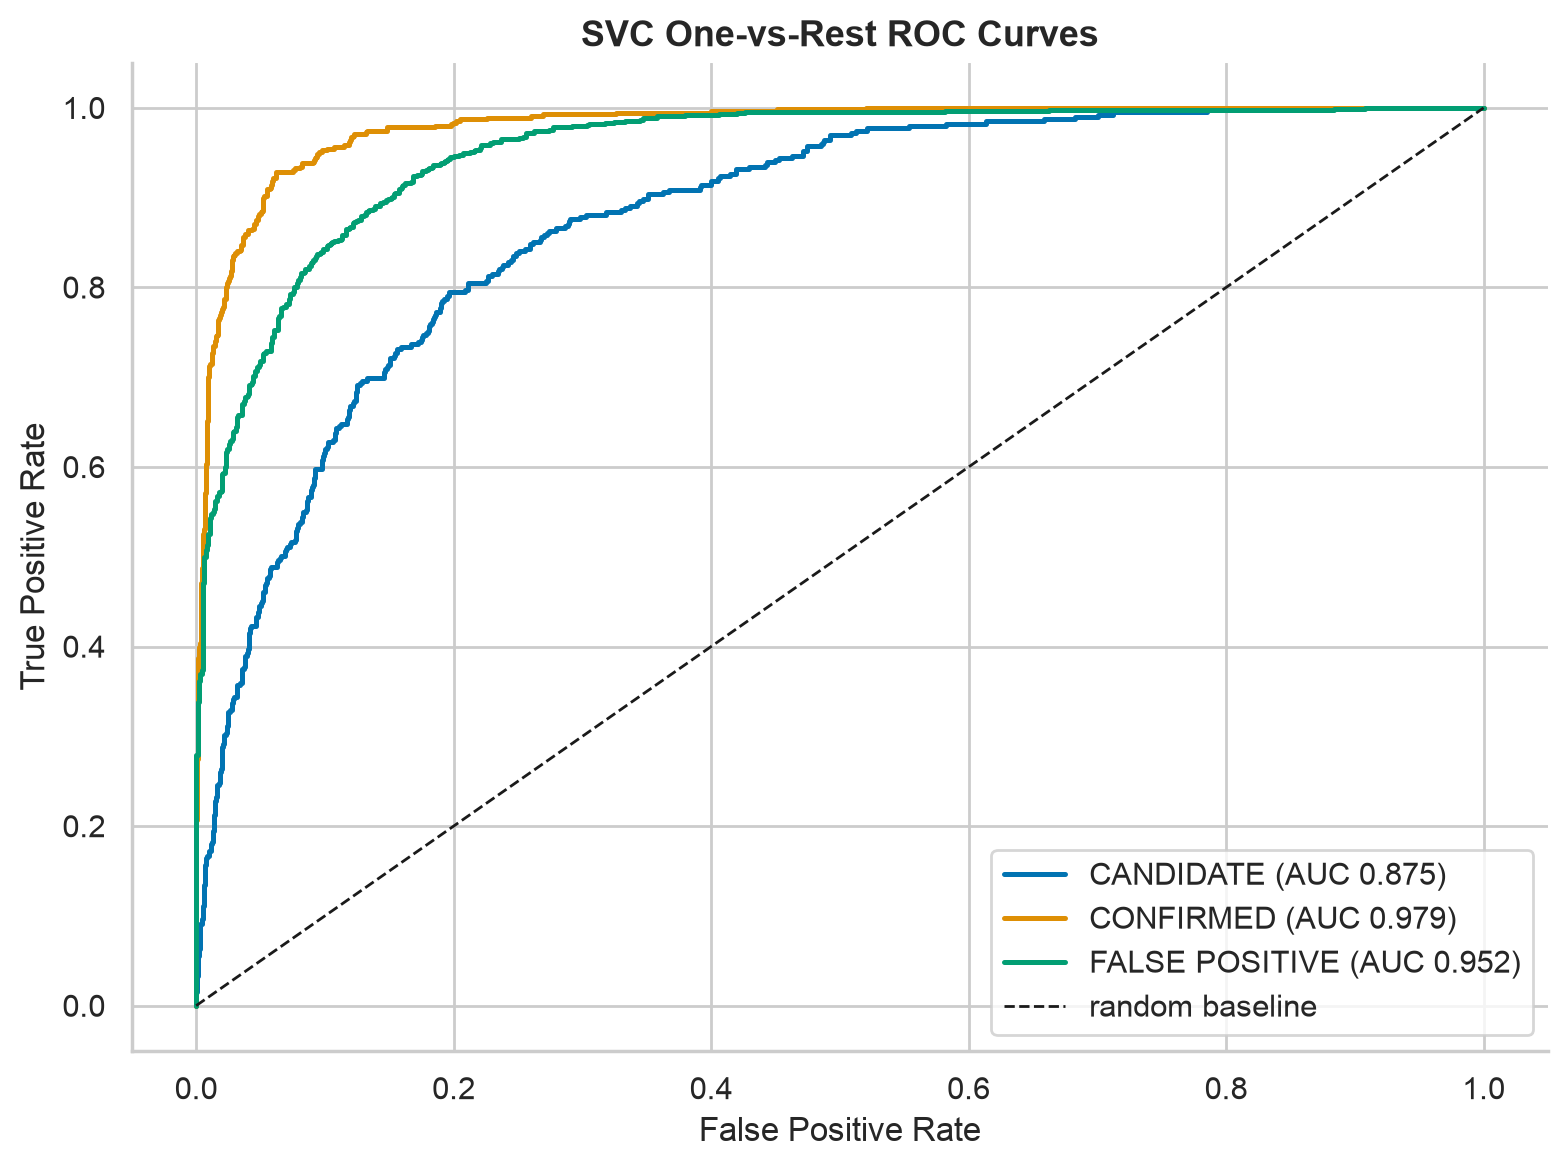

In [32]:
#one-vs-rest roc curves for svc, saved under figures/SVC/
svc_y_test_bin = label_binarize(y_test, classes=svc_classes)

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)
for idx, class_name in enumerate(svc_classes):
    fpr, tpr, _ = roc_curve(svc_y_test_bin[:, idx], svc_probabilities[:, idx])
    auc = roc_auc_score(svc_y_test_bin[:, idx], svc_probabilities[:, idx])
    ax.plot(fpr, tpr, lw=1.8, label=f"{class_name} (AUC {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="random baseline")
ax.set_title("SVC One-vs-Rest ROC Curves", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("figures/SVC/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
#full classification comparison including svc (same format as section 17)
svc_comparison_table = pd.DataFrame([
    gnb_metrics,
    tree_baseline_metrics,
    tuned_tree_metrics,
    svc_metrics,
]).round(4)

svc_comparison_table = svc_comparison_table.sort_values("F1_Weighted", ascending=False).reset_index(drop=True)
display(svc_comparison_table)

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,ROC_AUC_OvR
0,Support Vector Classifier,0.8223,0.8179,0.8223,0.8197,0.9442
1,Decision Tree Classifier - Tuned,0.8207,0.8180,0.8207,0.8190,0.9233
2,Decision Tree Classifier - Baseline,0.7930,0.7950,0.7930,0.7938,0.8383
3,Gaussian Naive Bayes,0.6142,0.7241,0.6142,0.6186,0.8769


### Results

The tuned SVC reaches **accuracy 0.82, weighted F1 0.82, and one-vs-rest ROC-AUC 0.94** on the held-out test
set. That is essentially tied with the tuned Decision Tree for the best weighted F1 (both about 0.82) and
comfortably ahead of Gaussian Naive Bayes (weighted F1 about 0.62, held back by its independence and
normality assumptions on correlated transit features).

Per class it is strong on `CONFIRMED` and `FALSE POSITIVE` (F1 about 0.88 each) but weaker on `CANDIDATE`
(F1 about 0.60). The confusion matrix shows candidates being split across the other two classes, which is
expected: a candidate is by definition an object not yet resolved either way, so it shares features with
both. The high ROC-AUC (0.94) shows the predicted probabilities still rank objects well even where the hard
label is uncertain.